<a href="https://colab.research.google.com/github/SuryaAndika3005/ImageProcessing/blob/main/2311533005_Image_Processing_Tugas_Pertemuan_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

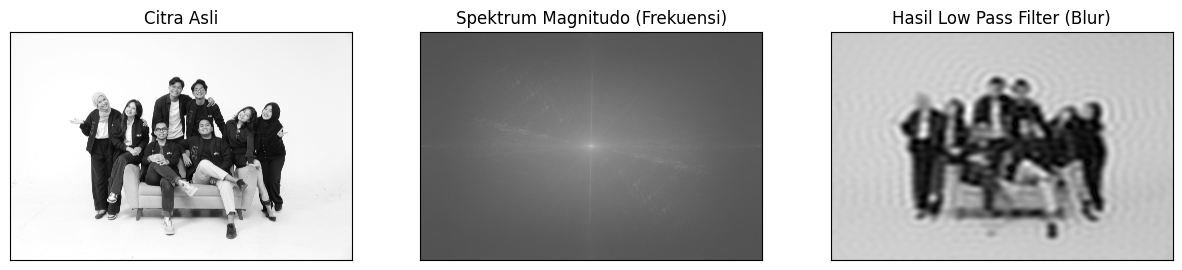

In [4]:
# 1. Load Citra (Pastikan nama file sesuai dengan yang kamu upload nanti)
# Gunakan cv2.IMREAD_GRAYSCALE karena FFT umumnya dilakukan pada satu channel

img = cv2.imread('Citra.JPG', cv2.IMREAD_GRAYSCALE)

if img is None:
  print("Citra tidak ditemukan! Pastikan nama file sudah benar.")
else:

# 2. Transformasi Fourier (FFT)
# dft menghasilkan output 2-channel (Real dan Imaginary)
  dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
# Geser komponen frekuensi rendah ke tengah (Centering)
dft_shift = np.fft.fftshift(dft)
# Menghitung spektrum magnitudo untuk visualisasi (skala logaritmik)
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))

# 3. Membuat Masker Low Pass Filter (LPF)
# Membuat lingkaran putih di tengah (lolos), sisanya hitam (tahan)
rows, cols = img.shape
crow, ccol = rows//2 , cols//2
mask = np.zeros((rows, cols, 2), np.uint8)
r = 30 # Radius filter (semakin kecil, semakin blur)
cv2.circle(mask, (ccol, crow), r, (1, 1), -1)

# 4. Terapkan Masker ke Spektrum Fourier
fshift = dft_shift * mask

# 5. Transformasi Fourier Balik (IDFT)
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])

# 6. Visualisasi Hasil
plt.figure(figsize=(15, 10))

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Asli'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Spektrum Magnitudo (Frekuensi)'), plt.xticks([]), plt.yticks([])

plt.subplot(133), plt.imshow(img_back, cmap='gray')
plt.title('Hasil Low Pass Filter (Blur)'), plt.xticks([]), plt.yticks([])

plt.show()